In [5]:
import pandas as pd

patients = pd.read_csv("patients.csv")
admissions = pd.read_csv("admissions.csv")
icustays = pd.read_csv("icustays.csv")

chartevents = pd.read_csv("chartevents.csv")
labevents = pd.read_csv("labevents.csv")
outputevents = pd.read_csv("outputevents.csv")

d_items = pd.read_csv("d_items.csv")
d_labitems = pd.read_csv("d_labitems.csv")

In [7]:
patients = patients[['subject_id','gender','anchor_age']]

patients = patients.drop_duplicates()

patients = patients[
    (patients['anchor_age'] >= 0) &
    (patients['anchor_age'] <= 120)
]

patients['gender'] = patients['gender'].str.upper()

In [9]:
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])

admissions = admissions.drop_duplicates()

admissions = admissions[
    admissions['dischtime'] > admissions['admittime']
]

In [11]:
icustays['intime'] = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])

icustays = icustays.drop_duplicates()

icustays = icustays[
    icustays['outtime'] > icustays['intime']
]

In [13]:
d_items[d_items['label'].str.contains(
    'Heart Rate',
    case=False,
    na=False
)]

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
2,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
3,220046,Heart rate Alarm - High,HR Alarm - High,chartevents,Alarms,bpm,Numeric,NaN,NaN
4,220047,Heart Rate Alarm - Low,HR Alarm - Low,chartevents,Alarms,bpm,Numeric,NaN,NaN


In [15]:
d_items[d_items['label'].str.contains(
    'Resp',
    case=False,
    na=False
)]

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
28,220210,Respiratory Rate,RR,chartevents,Respiratory,insp/min,Numeric,NaN,NaN
365,223804,TOF Response/Twitch,TOF Response/Twitch,chartevents,Pain/Sedation,NaN,Text,NaN,NaN
407,223900,GCS - Verbal Response,Verbal Response,chartevents,Neurological,NaN,Text,NaN,NaN
408,223901,GCS - Motor Response,Motor Response,chartevents,Neurological,NaN,Text,NaN,NaN
416,223916,Response to Stimuli (Type),Response to Stimuli (Type),chartevents,Neurological,NaN,Text,NaN,NaN
470,223985,Respiratory Pattern,Respiratory Pattern,chartevents,Pulmonary,NaN,Text,NaN,NaN
475,223990,Respiratory Effort,Respiratory Effort,chartevents,Pulmonary,NaN,Text,NaN,NaN
538,224079,Education Response,Education Response,chartevents,Restraint/Support Systems,NaN,Text,NaN,NaN
572,224161,Resp Alarm - High,Resp Alarm - High,chartevents,Alarms,insp/min,Numeric,NaN,NaN
573,224162,Resp Alarm - Low,Resp Alarm - Low,chartevents,Alarms,insp/min,Numeric,NaN,NaN


In [17]:
d_items[d_items['label'].str.contains(
    'Temperature',
    case=False,
    na=False
)]

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
337,223761,Temperature Fahrenheit,Temperature F,chartevents,Routine Vital Signs,°F,Numeric,NaN,NaN
338,223762,Temperature Celsius,Temperature C,chartevents,Routine Vital Signs,°C,Numeric,NaN,NaN
505,224027,Skin Temperature,Skin Temp,chartevents,Skin - Assessment,NaN,Text,NaN,NaN
767,224642,Temperature Site,Temp Site,chartevents,Routine Vital Signs,NaN,Text,NaN,NaN
790,224674,Changes in Temperature,Changes in Temperature,chartevents,Toxicology,NaN,Text,NaN,NaN
1814,226329,Blood Temperature CCO (C),Blood Temp CCO (C),chartevents,Routine Vital Signs,°C,Numeric,NaN,NaN
2097,227054,TemperatureF_ApacheIV,TemperatureF_ApacheIV,chartevents,Scores - APACHE IV (2),°F,Numeric,NaN,NaN
2776,228242,Pt. Temperature (BG) (SOFT),Pt. Temperature (BG) (SOFT),chartevents,Labs,NaN,Numeric,NaN,NaN
3466,229236,Cerebral Temperature (C),Cerebral T (C),chartevents,Hemodynamics,°C,Numeric,NaN,NaN


In [19]:
d_items[d_items['label'].str.contains(
    'SpO2',
    case=False,
    na=False
)]

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
1810,226253,SpO2 Desat Limit,SpO2 Desat Limit,chartevents,Alarms,%,Numeric,NaN,NaN
3920,229862,Forehead SpO2 Sensor in Place,Forehead SpO2 Sensor in Place,chartevents,Routine Vital Signs,NaN,Checkbox,NaN,NaN


In [21]:
d_items[d_items['label'].str.contains(
    'Mean',
    case=False,
    na=False
)]

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
8,220052,Arterial Blood Pressure mean,ABPm,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
13,220061,Pulmonary Artery Pressure mean,PAPm,chartevents,Hemodynamics,mmHg,Numeric,10.0,20.0
26,220181,Non Invasive Blood Pressure mean,NBPm,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
635,224322,IABP Mean,MAP - Assisted,chartevents,IABP,mmHg,Numeric,NaN,NaN
806,224697,Mean Airway Pressure,Mean Airway Pressure,chartevents,Respiratory,cmH2O,Numeric,NaN,NaN
1214,225312,ART BP Mean,ART BP Mean,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
1338,225491,Patient identified correctly by 2 means (THCEN),Patient identified correctly by 2 means (THCEN),chartevents,Thoracentesis,NaN,Text,NaN,NaN
1341,225499,Patient identified correctly by 2 means (PACEN),Patient identified correctly by 2 means (PACEN),chartevents,Paracentesis,NaN,Text,NaN,NaN
1797,226189,Patient identified correctly by 2 means (Intub...,Patient identified correctly by 2 means (Intub...,chartevents,Intubation,NaN,Text,NaN,NaN
1994,226849,RA (mean) pressure (PA Line),RA (mean) pressure (PA Line),chartevents,PA Line Insertion,mmHg,Numeric,NaN,NaN


In [23]:
HR = [220045]
RR = [220210]
TEMP = [223762]
MAP = [220181]
SPO2 = [220277]

vital_ids = HR + RR + TEMP + MAP + SPO2

In [25]:
vitals = chartevents[
    chartevents['itemid'].isin(vital_ids)
]

In [27]:
vitals['valuenum'] = pd.to_numeric(
    vitals['valuenum'],
    errors='coerce'
)

/var/folders/20/s7scsmvj1ls36r97rl187b9c0000gn/T/ipykernel_71882/2463921791.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vitals['valuenum'] = pd.to_numeric(


In [29]:
vitals = vitals.dropna(subset=['valuenum'])

In [31]:
vitals = vitals[
    ~(
        (vitals['itemid']==220045) &
        (
            (vitals['valuenum'] < 30) |
            (vitals['valuenum'] > 250)
        )
    )
]

In [33]:
vitals = vitals[
    ~(
        (vitals['itemid']==220210) &
        (
            (vitals['valuenum'] < 4) |
            (vitals['valuenum'] > 80)
        )
    )
]

In [35]:
vitals = vitals[
    ~(
        (vitals['itemid']==223762) &
        (
            (vitals['valuenum'] < 30) |
            (vitals['valuenum'] > 45)
        )
    )
]

In [37]:
vitals = vitals[
    ~(
        (vitals['itemid']==220277) &
        (
            (vitals['valuenum'] < 0) |
            (vitals['valuenum'] > 100)
        )
    )
]

In [39]:
wanted = [
    'Lactate',
    'Creatinine',
    'Platelet Count',
    'WBC',
    'Bilirubin',
    'Bicarbonate'
]

for lab in wanted:
    print(
        d_labitems[
            d_labitems['label'].str.contains(
                lab,
                case=False,
                na=False
            )
        ][['itemid','label']]
    )

      itemid                           label
11     50813                         Lactate
41     50843  Lactate Dehydrogenase, Ascites
151    50954      Lactate Dehydrogenase (LD)
242    51054  Lactate Dehydrogenase, Pleural
911    51795      Lactate Dehydrogenase, CSF
1035   51944    Lactate Dehydrogenase, Stool
1516   52442                         Lactate
1615   53154                         Lactate
      itemid                            label
39     50841              Creatinine, Ascites
110    50912                       Creatinine
209    51021          Creatinine, Joint Fluid
220    51032           Creatinine, Body Fluid
240    51052              Creatinine, Pleural
255    51067                 24 hr Creatinine
258    51070        Albumin/Creatinine, Urine
261    51073  Amylase/Creatinine Ratio, Urine
268    51080             Creatinine Clearance
269    51081                Creatinine, Serum
270    51082                Creatinine, Urine
287    51099         Protein/Creatinine Rat

In [41]:
lab_ids = [
    50813,   # Lactate
    50912,   # Creatinine
    51265,   # Platelets
    51300,   # WBC
    50885,   # Bilirubin
    50882    # Bicarbonate
]

labs = labevents[
    labevents['itemid'].isin(lab_ids)
]

In [43]:
labs['valuenum'] = pd.to_numeric(
    labs['valuenum'],
    errors='coerce'
)

labs = labs.dropna(subset=['valuenum'])

/var/folders/20/s7scsmvj1ls36r97rl187b9c0000gn/T/ipykernel_71882/2614884061.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labs['valuenum'] = pd.to_numeric(


In [45]:
labs = labs[
    (labs['valuenum'] >= 0)
]

In [47]:
urine_ids = [
    226559,
    226560,
    226561
]

In [49]:
urine = outputevents[
    outputevents['itemid'].isin(urine_ids)
]

In [51]:
urine = urine[
    urine['value'] >= 0
]

In [53]:
vitals['charttime'] = pd.to_datetime(vitals['charttime'])

icu = icustays[['stay_id','intime']]

vitals = vitals.merge(
    icu,
    on='stay_id'
)

In [55]:
vitals = vitals[
    vitals['charttime']
    <=
    vitals['intime']
    + pd.Timedelta(hours=6)
]

In [57]:
mean_features = (
    vitals
    .groupby(['stay_id','itemid'])
    ['valuenum']
    .mean()
    .unstack()
)

In [59]:
max_features = (
    vitals
    .groupby(['stay_id','itemid'])
    ['valuenum']
    .max()
    .unstack()
)

In [61]:
min_features = (
    vitals
    .groupby(['stay_id','itemid'])
    ['valuenum']
    .min()
    .unstack()
)

In [63]:
std_features = (
    vitals
    .groupby(['stay_id','itemid'])
    ['valuenum']
    .std()
    .unstack()
)

In [65]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

NameError: name 'X' is not defined

In [69]:
for v in [
    'patients',
    'icustays',
    'vitals',
    'labs',
    'mean_features',
    'max_features',
    'min_features',
    'std_features',
    'X'
]:
    print(v, v in globals())

patients True
icustays True
vitals True
labs True
mean_features True
max_features True
min_features True
std_features True
X False


In [71]:
print(mean_features.shape)
print(max_features.shape)
print(min_features.shape)
print(std_features.shape)

(1117, 5)
(1117, 5)
(1117, 5)
(1117, 5)


In [73]:
mean_features.columns = [f"{c}_mean" for c in mean_features.columns]

max_features.columns = [f"{c}_max" for c in max_features.columns]

min_features.columns = [f"{c}_min" for c in min_features.columns]

std_features.columns = [f"{c}_std" for c in std_features.columns]

In [75]:
X = pd.concat(
    [
        mean_features,
        max_features,
        min_features,
        std_features
    ],
    axis=1
)

In [77]:
print(X.shape)
X.head()

(1117, 20)


,220045.0_mean,220181.0_mean,220210.0_mean,220277.0_mean,223762.0_mean,220045.0_max,220181.0_max,220210.0_max,220277.0_max,223762.0_max,220045.0_min,220181.0_min,220210.0_min,220277.0_min,223762.0_min,220045.0_std,220181.0_std,220210.0_std,220277.0_std,223762.0_std
stay_id,,,,,,,,,,,,,,,,,,,,
30008792.0,82.250000,58.416667,16.166667,100.000000,NaN,91.0,73.0,19.0,100.0,NaN,77.0,47.0,14.0,100.0,NaN,4.433857,8.500891,1.466804,0.000000,NaN
30020739.0,70.833333,NaN,15.166667,99.833333,NaN,80.0,NaN,18.0,100.0,NaN,64.0,NaN,14.0,99.0,NaN,7.222650,NaN,1.602082,0.408248,NaN
30033055.0,135.500000,76.333333,29.333333,NaN,NaN,141.0,91.0,34.0,NaN,NaN,129.0,61.0,22.0,NaN,NaN,3.894440,15.011107,4.062019,NaN,NaN
30057454.0,105.916667,NaN,19.250000,93.500000,NaN,114.0,NaN,23.0,96.0,NaN,100.0,NaN,14.0,90.0,NaN,4.316108,NaN,2.767506,1.930615,NaN
30072752.0,64.285714,97.285714,15.285714,95.142857,NaN,70.0,106.0,19.0,99.0,NaN,60.0,91.0,13.0,91.0,NaN,3.988077,6.019809,1.976047,2.734262,NaN


In [79]:
X.isnull().sum().sort_values(ascending=False).head(20)

223762.0_std     1055
223762.0_mean    1046
223762.0_min     1046
223762.0_max     1046
220181.0_std      221
220181.0_max      192
220181.0_mean     192
220181.0_min      192
220210.0_std       14
220277.0_std       13
220277.0_mean       6
220277.0_min        6
220045.0_std        6
220277.0_max        6
220210.0_max        5
220210.0_min        5
220210.0_mean       5
220045.0_mean       0
220045.0_max        0
220045.0_min        0
dtype: int64

In [81]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)


In [83]:
X.isnull().sum().sum()

0

In [85]:
X.to_csv(
    "clean_feature_matrix.csv",
    index=True
)

In [87]:
X.to_csv(
    "sepsis_features_clean.csv",
    index=False
)

In [89]:
print(X.shape)
X.head()

(1117, 20)


,220045.0_mean,220181.0_mean,220210.0_mean,220277.0_mean,223762.0_mean,220045.0_max,220181.0_max,220210.0_max,220277.0_max,223762.0_max,220045.0_min,220181.0_min,220210.0_min,220277.0_min,223762.0_min,220045.0_std,220181.0_std,220210.0_std,220277.0_std,223762.0_std
stay_id,,,,,,,,,,,,,,,,,,,,
30008792.0,82.250000,58.416667,16.166667,100.000000,35.98,91.0,73.0,19.0,100.0,36.4,77.0,47.0,14.0,100.0,35.6,4.433857,8.500891,1.466804,0.000000,0.28547
30020739.0,70.833333,79.428571,15.166667,99.833333,35.98,80.0,92.0,18.0,100.0,36.4,64.0,68.0,14.0,99.0,35.6,7.222650,8.021982,1.602082,0.408248,0.28547
30033055.0,135.500000,76.333333,29.333333,97.285714,35.98,141.0,91.0,34.0,100.0,36.4,129.0,61.0,22.0,95.0,35.6,3.894440,15.011107,4.062019,1.505545,0.28547
30057454.0,105.916667,79.428571,19.250000,93.500000,35.98,114.0,92.0,23.0,96.0,36.4,100.0,68.0,14.0,90.0,35.6,4.316108,8.021982,2.767506,1.930615,0.28547
30072752.0,64.285714,97.285714,15.285714,95.142857,35.98,70.0,106.0,19.0,99.0,36.4,60.0,91.0,13.0,91.0,35.6,3.988077,6.019809,1.976047,2.734262,0.28547


In [91]:
# Merge ICU identifiers
X = (
    X.reset_index()
    .merge(
        icustays[['stay_id', 'hadm_id', 'subject_id']],
        on='stay_id',
        how='left'
    )
    .merge(
        patients[['subject_id', 'anchor_age', 'gender']],
        on='subject_id',
        how='left'
    )
)

# Encode gender
X['gender'] = X['gender'].map({'M': 1, 'F': 0})

print(X.shape)
X.head()

(1117, 25)


,stay_id,220045.0_mean,220181.0_mean,220210.0_mean,220277.0_mean,223762.0_mean,220045.0_max,220181.0_max,220210.0_max,220277.0_max,...,223762.0_min,220045.0_std,220181.0_std,220210.0_std,220277.0_std,223762.0_std,hadm_id,subject_id,anchor_age,gender
0,30008792.0,82.250000,58.416667,16.166667,100.000000,35.98,91.0,73.0,19.0,100.0,...,35.6,4.433857,8.500891,1.466804,0.000000,0.28547,22953864,10106899,86,0
1,30020739.0,70.833333,79.428571,15.166667,99.833333,35.98,80.0,92.0,18.0,100.0,...,35.6,7.222650,8.021982,1.602082,0.408248,0.28547,29357112,10061633,59,1
2,30033055.0,135.500000,76.333333,29.333333,97.285714,35.98,141.0,91.0,34.0,100.0,...,35.6,3.894440,15.011107,4.062019,1.505545,0.28547,20376756,10126201,50,1
3,30057454.0,105.916667,79.428571,19.250000,93.500000,35.98,114.0,92.0,23.0,96.0,...,35.6,4.316108,8.021982,2.767506,1.930615,0.28547,28872262,10023117,53,1
4,30072752.0,64.285714,97.285714,15.285714,95.142857,35.98,70.0,106.0,19.0,99.0,...,35.6,3.988077,6.019809,1.976047,2.734262,0.28547,29252361,10012789,71,1


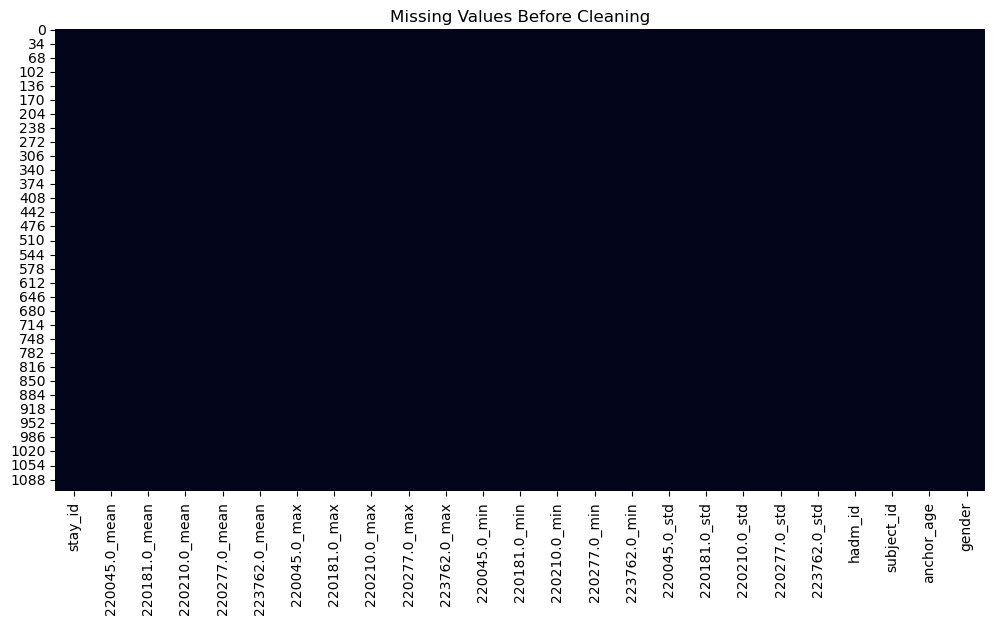

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(X.isnull(), cbar=False)
plt.title("Missing Values Before Cleaning")
plt.show()

In [97]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

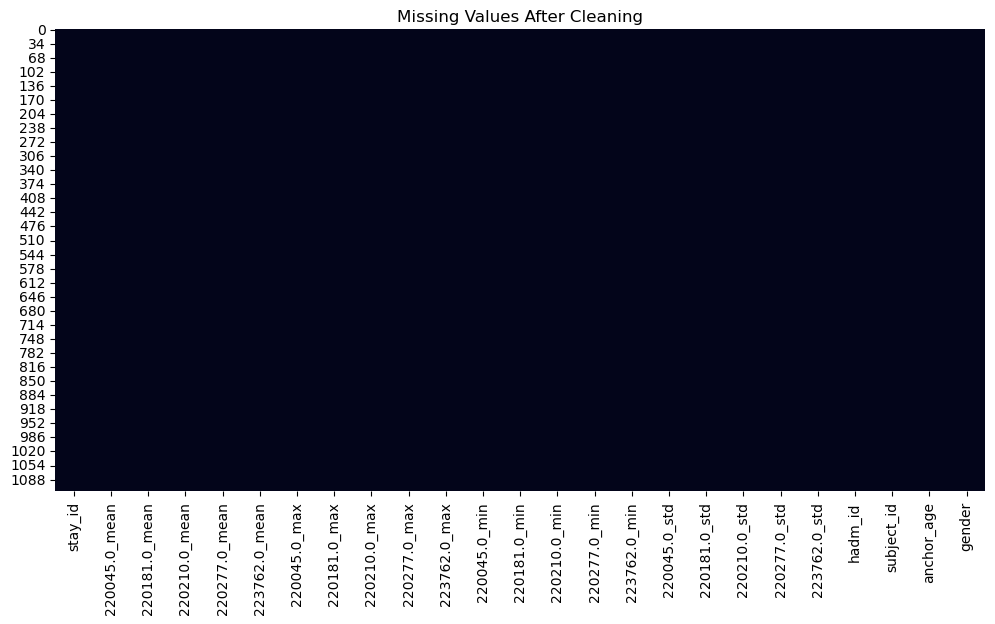

In [99]:
plt.figure(figsize=(12,6))
sns.heatmap(X.isnull(), cbar=False)
plt.title("Missing Values After Cleaning")
plt.show()

In [107]:
plt.figure(figsize=(8,5))

X['HR_mean'].hist(bins=50)

plt.title("Heart Rate After Cleaning")
plt.show()

KeyError: 'HR'

<Figure size 800x500 with 0 Axes>

In [109]:
print(X.columns.tolist())

['stay_id', '220045.0_mean', '220181.0_mean', '220210.0_mean', '220277.0_mean', '223762.0_mean', '220045.0_max', '220181.0_max', '220210.0_max', '220277.0_max', '223762.0_max', '220045.0_min', '220181.0_min', '220210.0_min', '220277.0_min', '223762.0_min', '220045.0_std', '220181.0_std', '220210.0_std', '220277.0_std', '223762.0_std', 'hadm_id', 'subject_id', 'anchor_age', 'gender']


In [111]:
for col in X.columns:
    print(col)

stay_id
220045.0_mean
220181.0_mean
220210.0_mean
220277.0_mean
223762.0_mean
220045.0_max
220181.0_max
220210.0_max
220277.0_max
223762.0_max
220045.0_min
220181.0_min
220210.0_min
220277.0_min
223762.0_min
220045.0_std
220181.0_std
220210.0_std
220277.0_std
223762.0_std
hadm_id
subject_id
anchor_age
gender


In [115]:
mean_features.columns = [f"{c}_mean" for c in mean_features.columns]
max_features.columns = [f"{c}_max" for c in max_features.columns]
min_features.columns = [f"{c}_min" for c in min_features.columns]
std_features.columns = [f"{c}_std" for c in std_features.columns]

In [117]:
[c for c in X.columns if '220045' in str(c)]

['220045.0_mean', '220045.0_max', '220045.0_min', '220045.0_std']

In [119]:
plt.figure(figsize=(8,5))

X['220045_mean'].hist(bins=50)

plt.title("Heart Rate Mean Distribution")
plt.show()

KeyError: '220045_mean'

<Figure size 800x500 with 0 Axes>